### Analysis of deconvoluted 10X Visium Bleo day21 data

ST data from [Franzen, Lindvall, et al. Nature Genetics (2024)](https://www.nature.com/articles/s41588-024-01819-2)

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sb

In [2]:
import cell2location as c2l

/home/niklas/miniconda3/envs/c2l_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# making sure plots & clusters are reproducible
np.random.seed(42)

In [4]:
## plotting variables
sc.settings.figdir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig_spatial_overview/'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [5]:
## path variables
spatial_dir = '/mnt/smb/Niklas/20240911_10XVisum_Stockholm_mouse/'
fig_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig_spatial_overview/'

In [6]:
## paths reference regression and cell2location models
ref_run_name = f'{spatial_dir}/reference_signatures'
run_name = f'{spatial_dir}/cell2location_map'

### Load Visium data

In [7]:
adata_file = f'{run_name}/250111_10XVisium_d21_deconvolution.h5ad'

In [8]:
adata_st = sc.read(adata_file)

In [9]:
adata_st

AnnData object with n_obs × n_vars = 23107 × 11916
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', '_indices', '_scvi_batch', '_scvi_labels', 'AT1', 'AT2', 'AT2 activated', 'Krt8+ ADI', 'Basal', 'Club/Ciliated', 'Ciliated', 'NEC', 'Aerocyte capillary EC', 'Transitional capillary EC', 'General capillary EC', 'Proliferating capillary EC', 'Vwa1+/Col15a1+ ectopic capillary EC', 'Arterial EC', 'Venous EC', 'Lymphatic EC', 'Adventitial Fibroblasts', 'Adh7+ Fibroblasts', 'Lgr5+/Lgr6+ Fibroblasts', 'Lgr5+/Lgr6+ Fibroblasts activated', 'Lipofibroblasts', 'Lipo/Myofibroblast Transition', 'Cthrc1+ Myofibroblasts', 'Spp1+ Myofibroblasts', 'Pericytes', 'Pericytes activated', 'aSMCs', 'vSMCs', 'Mesothelial', 'Non-classical Monocytes', 'Classical Monocytes', 'Intermediate M

In [10]:
adata_st.obsm['q05_cell_abundance_w_sf']

,q05cell_abundance_w_sf_AT1,q05cell_abundance_w_sf_AT2,q05cell_abundance_w_sf_AT2 activated,q05cell_abundance_w_sf_Krt8+ ADI,q05cell_abundance_w_sf_Basal,q05cell_abundance_w_sf_Club/Ciliated,q05cell_abundance_w_sf_Ciliated,q05cell_abundance_w_sf_NEC,q05cell_abundance_w_sf_Aerocyte capillary EC,q05cell_abundance_w_sf_Transitional capillary EC,...,q05cell_abundance_w_sf_Cd4+ T cells,q05cell_abundance_w_sf_Cd8+ T cells,q05cell_abundance_w_sf_Cd4+/Cd8+ T cells,q05cell_abundance_w_sf_T reg cells,q05cell_abundance_w_sf_Th2 cells,q05cell_abundance_w_sf_Th17 cells,q05cell_abundance_w_sf_Themis+ T cells,q05cell_abundance_w_sf_Proliferating T cells,q05cell_abundance_w_sf_NK T cells,q05cell_abundance_w_sf_NK cells
spot_id,,,,,,,,,,,,,,,,,,,,,
V10A20-071-A1_AAACAATCTACTAGCA-1,4.113769,1.139344,0.366584,0.152523,0.140346,0.514938,0.230613,0.285543,1.004229,2.369811,...,0.105918,0.319765,0.097983,0.104582,0.099392,0.062116,0.086508,0.089139,0.083946,0.076569
V10A20-071-A1_AAACACCAATAACTGC-1,1.985945,0.893109,0.155001,0.247543,0.551929,1.831060,0.575216,0.042521,0.255931,0.946755,...,0.124810,0.886896,0.127265,0.073109,0.087379,0.053119,0.094364,0.031817,0.087758,0.183758
V10A20-071-A1_AAACAGAGCGACTCCT-1,3.724804,0.808966,0.136281,0.114779,0.323484,0.109360,0.014716,0.042559,0.379324,1.368024,...,0.078115,0.216633,0.062395,0.088471,0.058415,0.111647,0.039536,0.045233,0.049074,0.040001
V10A20-071-A1_AAACAGCTTTCAGAAG-1,1.955670,1.088263,0.265530,0.313392,1.006302,2.186129,1.191127,0.014109,0.520178,1.044697,...,0.085978,0.902439,0.086662,0.055918,0.076222,0.042772,0.044281,0.121479,0.043865,0.044904
V10A20-071-A1_AAACAGGGTCTATATT-1,4.047786,1.012169,0.190994,0.088427,0.279707,0.678788,0.394819,0.257603,0.440241,1.343747,...,0.078758,0.247904,0.069661,0.089210,0.081454,0.051439,0.083150,0.028412,0.060418,0.074271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
V10A20-053-D1_TTGTTGGCAATGACTG-1,1.812549,0.612049,0.077471,0.048083,0.052863,0.043178,0.072736,0.231774,0.372158,0.974310,...,0.238173,0.902981,0.210507,0.231348,0.092357,0.168985,0.208944,0.040148,0.260415,0.085097
V10A20-053-D1_TTGTTGTGTGTCAAGA-1,0.781709,0.199030,0.033911,0.030830,0.052662,0.256541,0.029590,0.011237,0.074926,0.123194,...,0.004935,0.020565,0.005570,0.012273,0.004930,0.006743,0.003852,0.001704,0.004693,0.006641
V10A20-053-D1_TTGTTTCCATACAACT-1,2.811050,0.783793,0.104385,0.237541,0.274359,0.280551,0.294764,0.141986,0.363501,0.652945,...,0.112629,0.502401,0.116562,0.158864,0.092867,0.162683,0.087331,0.287305,0.105004,0.055874


### Load metadata

In [11]:
metadata_file = f'{spatial_dir}/mm_visium_metadata.tsv'

In [12]:
metadata = pd.read_csv(metadata_file, sep = '\t')
metadata.head(5)

,sample_name,sample_id,slide_id,slide_ca,day,condition,group,animal,replicate,tissue,lobe,species
0,d7_ctrl_1,V10A20-072-A1,V10A20-072,A1,d7,control,d7_CTRL,d7_c1,a,lung,left,mouse
1,d7_ctrl_2,V10A20-074-A1,V10A20-074,A1,d7,control,d7_CTRL,d7_c2,a,lung,left,mouse
2,d7_ctrl_3,V10A20-073-A1,V10A20-073,A1,d7,control,d7_CTRL,d7_c3,a,lung,left,mouse
3,d7_bleo_1,V10A20-072-B1,V10A20-072,B1,d7,bleomycin,d7_BLM,d7_b1,a,lung,left,mouse
4,d7_bleo_2,V10A20-072-C1,V10A20-072,C1,d7,bleomycin,d7_BLM,d7_b2,a,lung,left,mouse


In [13]:
metadata = metadata[(metadata['day'] == 'd21') & (metadata['sample_name'].isin(['d21_ctrl_1','d21_ctrl_2','d21_ctrl_3','d21_bleo_4b','d21_bleo_5b','d21_bleo_6b']))]
metadata.head(6)

,sample_name,sample_id,slide_id,slide_ca,day,condition,group,animal,replicate,tissue,lobe,species
12,d21_ctrl_1,V10A20-071-A1,V10A20-071,A1,d21,control,d21_CTRL,d21_c1,a,lung,left,mouse
13,d21_ctrl_2,V10A20-052-A1,V10A20-052,A1,d21,control,d21_CTRL,d21_c2,a,lung,left,mouse
14,d21_ctrl_3,V10A20-053-A1,V10A20-053,A1,d21,control,d21_CTRL,d21_c3,a,lung,left,mouse
21,d21_bleo_4b,V10A20-053-B1,V10A20-053,B1,d21,bleomycin,d21_BLM,d21_b4,b,lung,left,mouse
22,d21_bleo_5b,V10A20-053-C1,V10A20-053,C1,d21,bleomycin,d21_BLM,d21_b5,b,lung,left,mouse
23,d21_bleo_6b,V10A20-053-D1,V10A20-053,D1,d21,bleomycin,d21_BLM,d21_b6,b,lung,left,mouse


### Exploratory analysis

In [14]:
## var.names = SYMBOL
adata_st.var.set_index('SYMBOL',inplace=True)
adata_st

AnnData object with n_obs × n_vars = 23107 × 11916
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', '_indices', '_scvi_batch', '_scvi_labels', 'AT1', 'AT2', 'AT2 activated', 'Krt8+ ADI', 'Basal', 'Club/Ciliated', 'Ciliated', 'NEC', 'Aerocyte capillary EC', 'Transitional capillary EC', 'General capillary EC', 'Proliferating capillary EC', 'Vwa1+/Col15a1+ ectopic capillary EC', 'Arterial EC', 'Venous EC', 'Lymphatic EC', 'Adventitial Fibroblasts', 'Adh7+ Fibroblasts', 'Lgr5+/Lgr6+ Fibroblasts', 'Lgr5+/Lgr6+ Fibroblasts activated', 'Lipofibroblasts', 'Lipo/Myofibroblast Transition', 'Cthrc1+ Myofibroblasts', 'Spp1+ Myofibroblasts', 'Pericytes', 'Pericytes activated', 'aSMCs', 'vSMCs', 'Mesothelial', 'Non-classical Monocytes', 'Classical Monocytes', 'Intermediate M

In [15]:
## define healthy and fibrotic slides
healthy_slides = adata_st.obs['sample'].unique()[0:3]
fibrotic_slides = adata_st.obs['sample'].unique()[3:6]

### Define niches

In [16]:
# combine 'Eosinophils' and 'Vwa1+/Col15a1+ ectopic capillary EC' to define hotspots where co-localize
adata_st.obsm['q05_cell_abundance_w_sf']['q05cell_abundance_w_sf_Eosinophils * Vwa1+/Col15a1+ capEC']= \
adata_st.obsm['q05_cell_abundance_w_sf']['q05cell_abundance_w_sf_Eosinophils']*adata_st.obsm['q05_cell_abundance_w_sf']['q05cell_abundance_w_sf_Vwa1+/Col15a1+ ectopic capillary EC']

#### Helper function from TeichLab to annotate and characterize cell type niche
See
https://github.com/Teichlab/HCA_Heart_ver2/blob/main/Visium/4_each-niche-analysis/myocardial-stress_niche/Defining-niche.ipynb
and
https://github.com/Teichlab/HCA_Heart_ver2/blob/main/Visium/2_cellstate_spatial_enrichment/ROIenrichment.py

In [17]:
from scipy.spatial import distance_matrix
from scipy.stats import chi2_contingency
import statsmodels.stats.multitest as smt

In [18]:
## helper functions from TeichLab
def annotate_celltype_niche(adata_vis,
                            celltype,
                            abundance_thresh,
                            n_spot_thresh,
                            slide=None,
                            slide_column='sample',
                            # cell2loc_resname='q05_cell_abundance_w_sf',
                            upper_limit_distance=2 ## need improve ##
                           ):
    '''
    * adata_vis: with cell2location output in the obsm
    
    '''
    adata = adata_vis.copy()
    
    
    # check adata
    if 'q05_cell_abundance_w_sf' not in adata.obsm:
        if celltype not in adata.var_names:
            raise KeyError(f'invalid <adata_vis> or <cell2loc_out>')
    
    if celltype not in adata.var_names:
        ## take obs data and cell2loc output
        obs = adata.obs.copy()
        cell2loc_res=adata.obsm['q05_cell_abundance_w_sf']
        cell2loc_res.columns=[x.replace('q05cell_abundance_w_sf_','') for x in cell2loc_res.columns]
        obs[cell2loc_res.columns]=cell2loc_res
    else:
        ## this means 'celltype' is a feature in var_names (eg gene)
        obs = adata.obs.copy()
        gene_loc = adata_reg.var_names.get_loc(celltype)
        obs[celltype]=adata_reg.X[:,gene_loc].todense()
    
    ## subset for each slide
    if slide!=None:
        obs = obs[obs[slide_column]==slide]
    
    ## select relevant columns
    obs = obs[['array_row','array_col',slide_column,celltype]]
    
    ## binarise the celltype abundance with abundance_thresh
    obs[f'{celltype}_bi']=obs[celltype]>abundance_thresh
    
    ## subset celltype 'existing' spots
    obs_s=obs[obs[f'{celltype}_bi']]
    
    ## distance matrix between spot pairs
    dm = distance_matrix(obs_s[['array_row','array_col']],obs_s[['array_row','array_col']])
    
    ## count how many neighbors 
    dm = (dm <= upper_limit_distance)&(dm > 0) # define distance to neighbors (need improvement...)
    obs_s[f'{celltype}_n_neighbor'] = np.sum(dm,axis=0)
    
    ## binarise the presence of niche based on the 'n_spot_thresh'
    ar = np.sum(dm,axis=0)>=(n_spot_thresh-1)
    for i in range(dm.shape[0]):
        if np.sum(np.sum(dm[ar],axis=0)>0)>np.sum(ar):
            ar = ar|(np.sum(dm[ar],axis=0)>0)
        else:
            print(f'iteration time: {i}')
            break
    obs_s[f'{celltype}_niche']=ar
    
    ## make columns in adata
    '''
    if f'{celltype}_n_neighbor' not in adata.obs.columns:
        adata.obs[f'{celltype}_n_neighbor']=0
    if f'{celltype}_niche' not in adata_vis.obs.columns:
        adata.obs[f'{celltype}_niche']='0'
    '''
    adata.obs[f'{celltype}_n_neighbor']=0
    adata.obs[f'{celltype}_niche']='0'
    adata.obs.loc[obs_s.index,f'{celltype}_n_neighbor']=obs_s[f'{celltype}_n_neighbor']
    adata.obs.loc[obs_s.index,f'{celltype}_niche']=obs_s[f'{celltype}_niche'].astype('int').astype('str')
    adata.obs.loc[obs.index,f'{celltype}_abundance']=obs[celltype]
    
    return adata

In [19]:
input_celltype = 'Eosinophils * Vwa1+/Col15a1+ capEC'

In [20]:
## annotate cell type niche using same parameters as in original publication
adata_st = annotate_celltype_niche(adata_st,
                                   celltype=input_celltype,
                                   abundance_thresh=0.03,
                                   n_spot_thresh=5,
                                   slide_column='sample')

iteration time: 6


/tmp/ipykernel_2082487/4105926984.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_s[f'{celltype}_n_neighbor'] = np.sum(dm,axis=0)
/tmp/ipykernel_2082487/4105926984.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs_s[f'{celltype}_niche']=ar


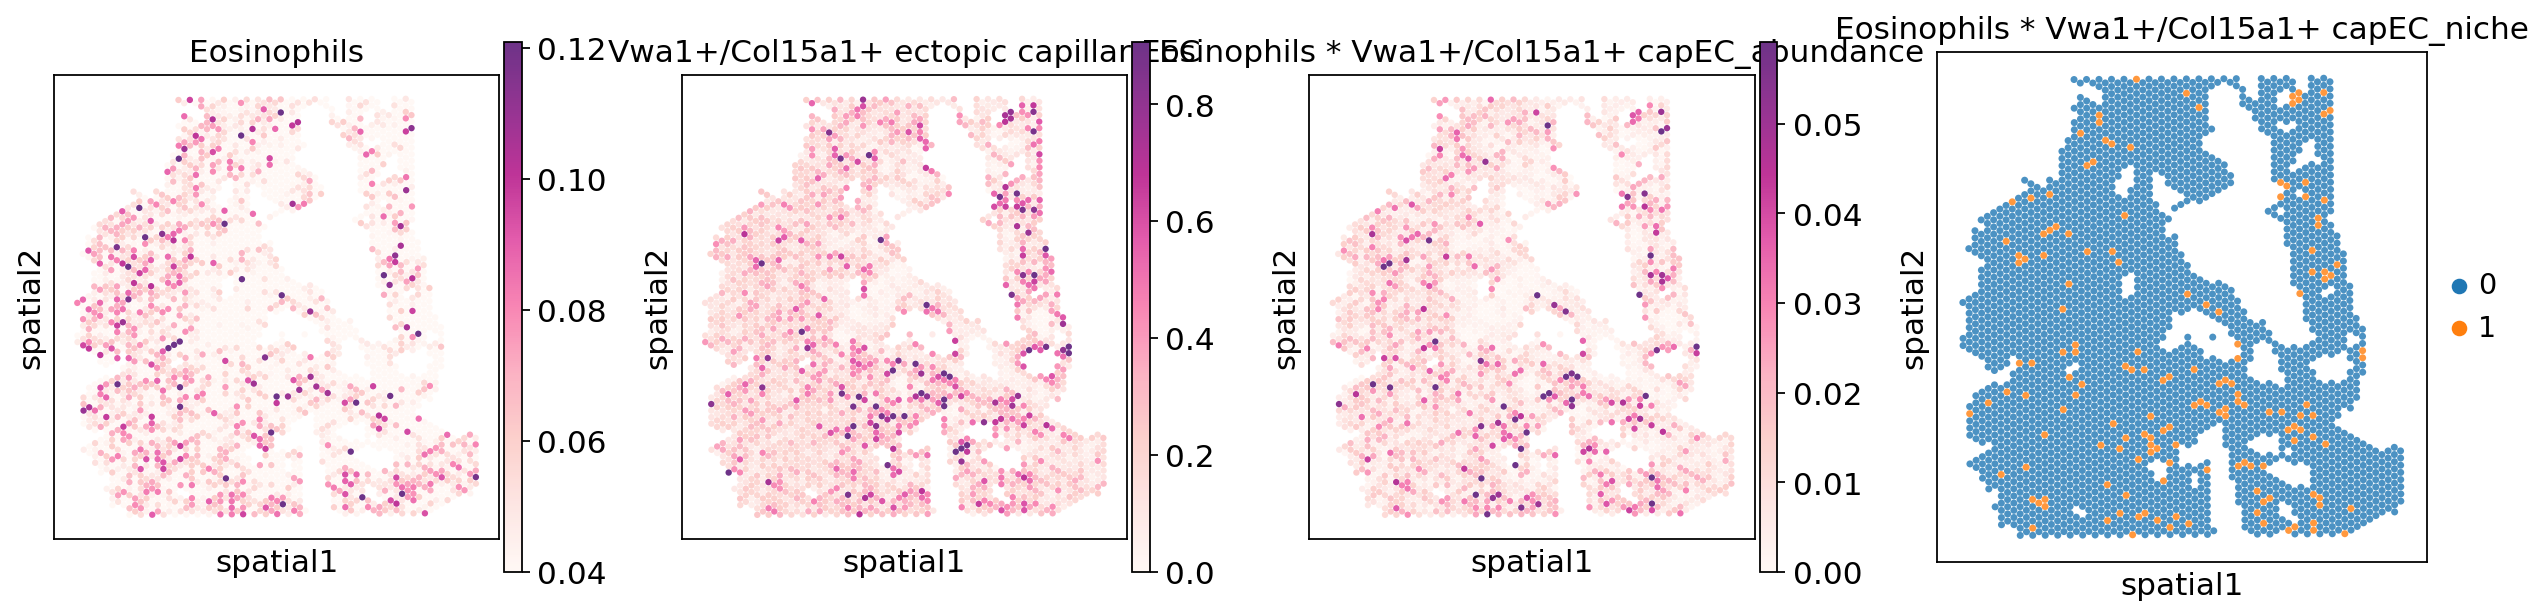

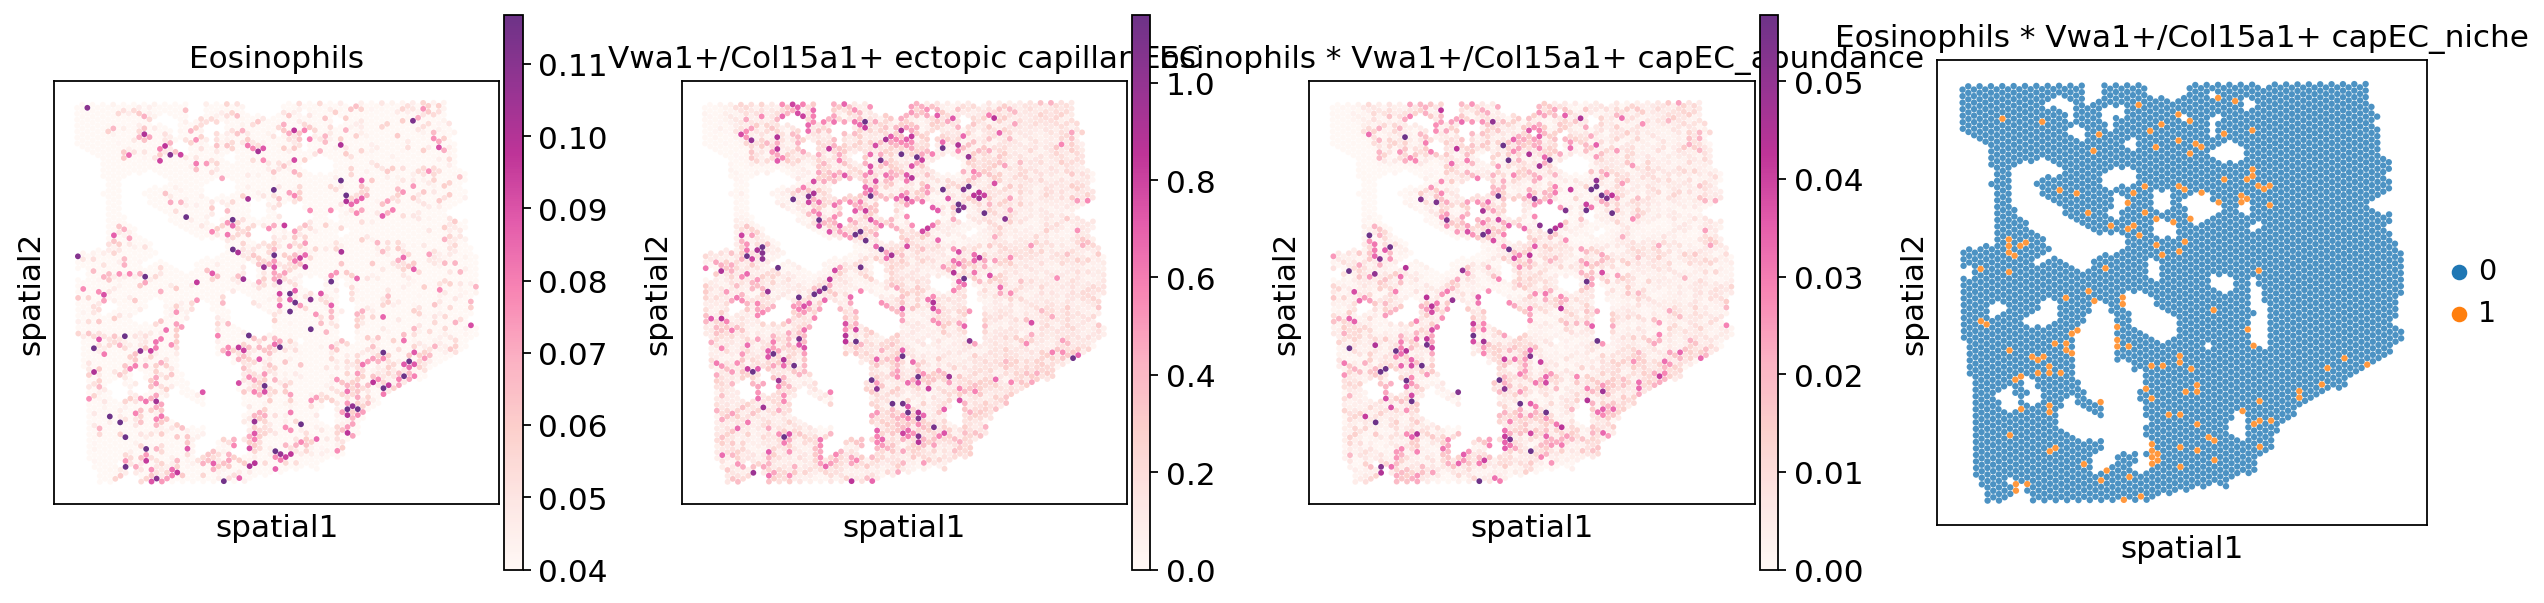

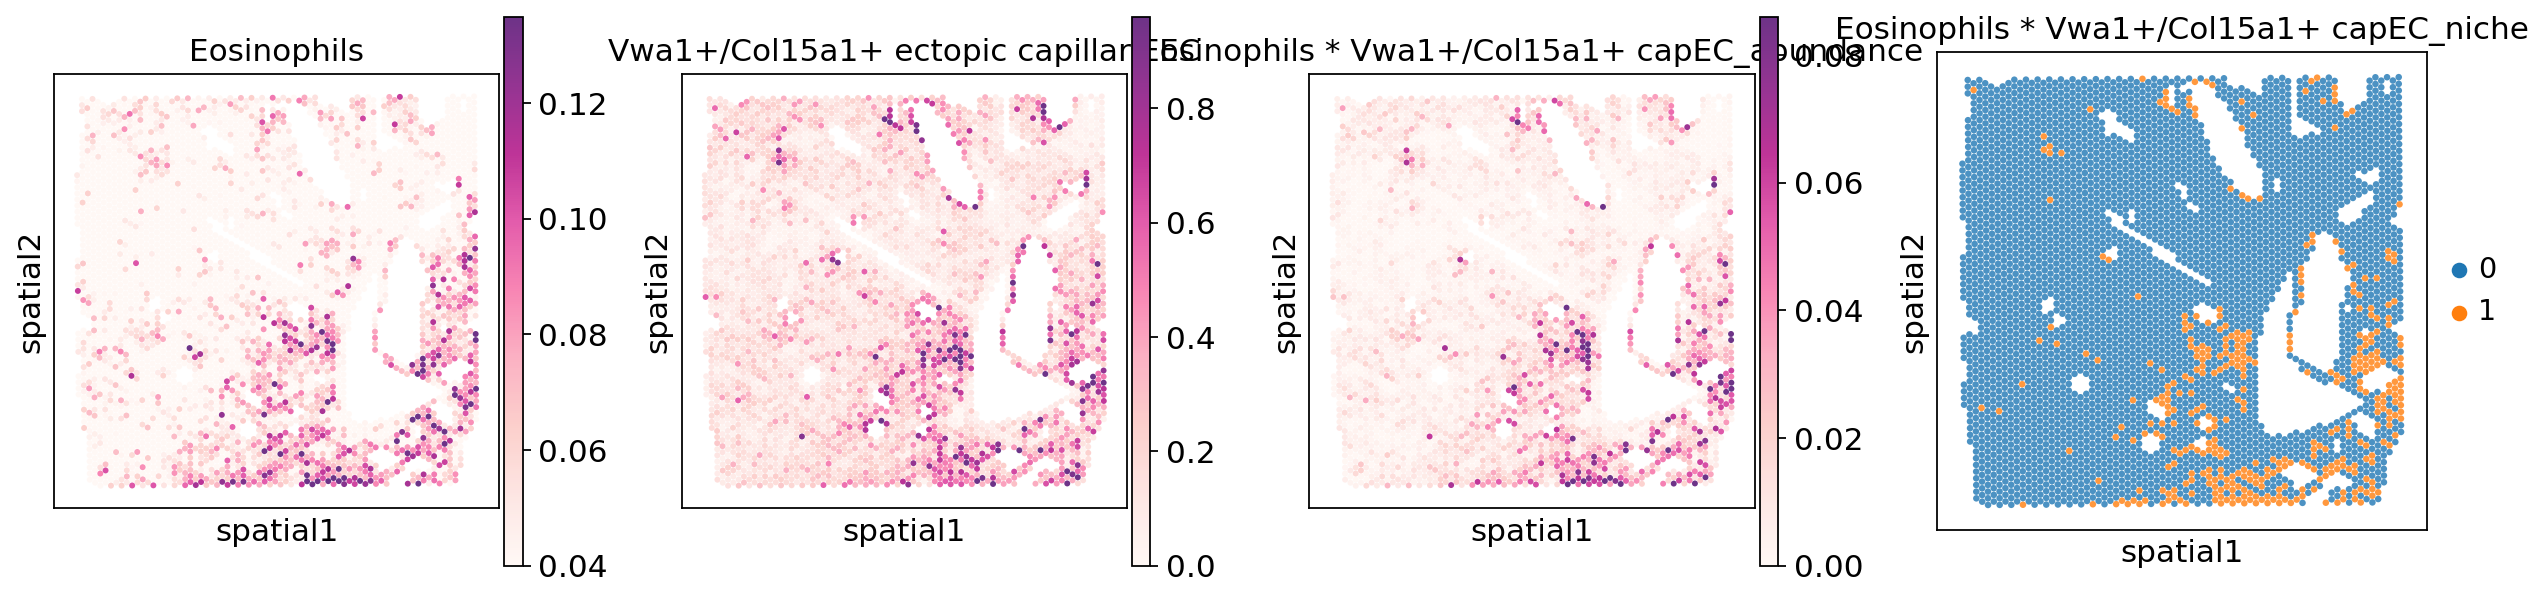

In [21]:
## focus on fibrotic slides
for s in fibrotic_slides:

    ## select slide 
    slide = c2l.utils.select_slide(adata_st, s, batch_key='sample')

    ## plot in spatial coordinates
    with mpl.rc_context({'axes.facecolor':  'white',
                         'figure.figsize': [6, 6]}):
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        
        sc.pl.spatial(slide,
                      color=['Eosinophils'],
                      cmap ='RdPu',
                      vmin=0.04,
                      vmax='p99.2',
                      size=1.5,
                      alpha=0.8,
                      img_key=None,
                      alpha_img=1,
                      ax=axes[0],
                      show=False
                     )
    
        sc.pl.spatial(slide,
                      color=['Vwa1+/Col15a1+ ectopic capillary EC'],
                      cmap ='RdPu',
                      vmin=0,
                      vmax='p99.2',
                      size=1.5,
                      alpha=0.8,
                      img_key=None,
                      alpha_img=1,
                      ax=axes[1],
                      show=False
                     )

        sc.pl.spatial(slide,
                      color=['Eosinophils * Vwa1+/Col15a1+ capEC_abundance'],
                      cmap ='RdPu',
                      vmin=0,
                      vmax='p99.2',
                      size=1.5,
                      alpha=0.8,
                      img_key=None,
                      alpha_img=1,
                      ax=axes[2],
                      show=False
                     )

        sc.pl.spatial(slide,
                      color=['Eosinophils * Vwa1+/Col15a1+ capEC_niche'],
                      vmin=0,
                      vmax='p99.2',
                      size=1.5,
                      alpha=0.8,
                      img_key=None,
                      alpha_img=1,
                      ax=axes[3],
                      show=False
                     )
        
        plt.tight_layout()
        plt.show()

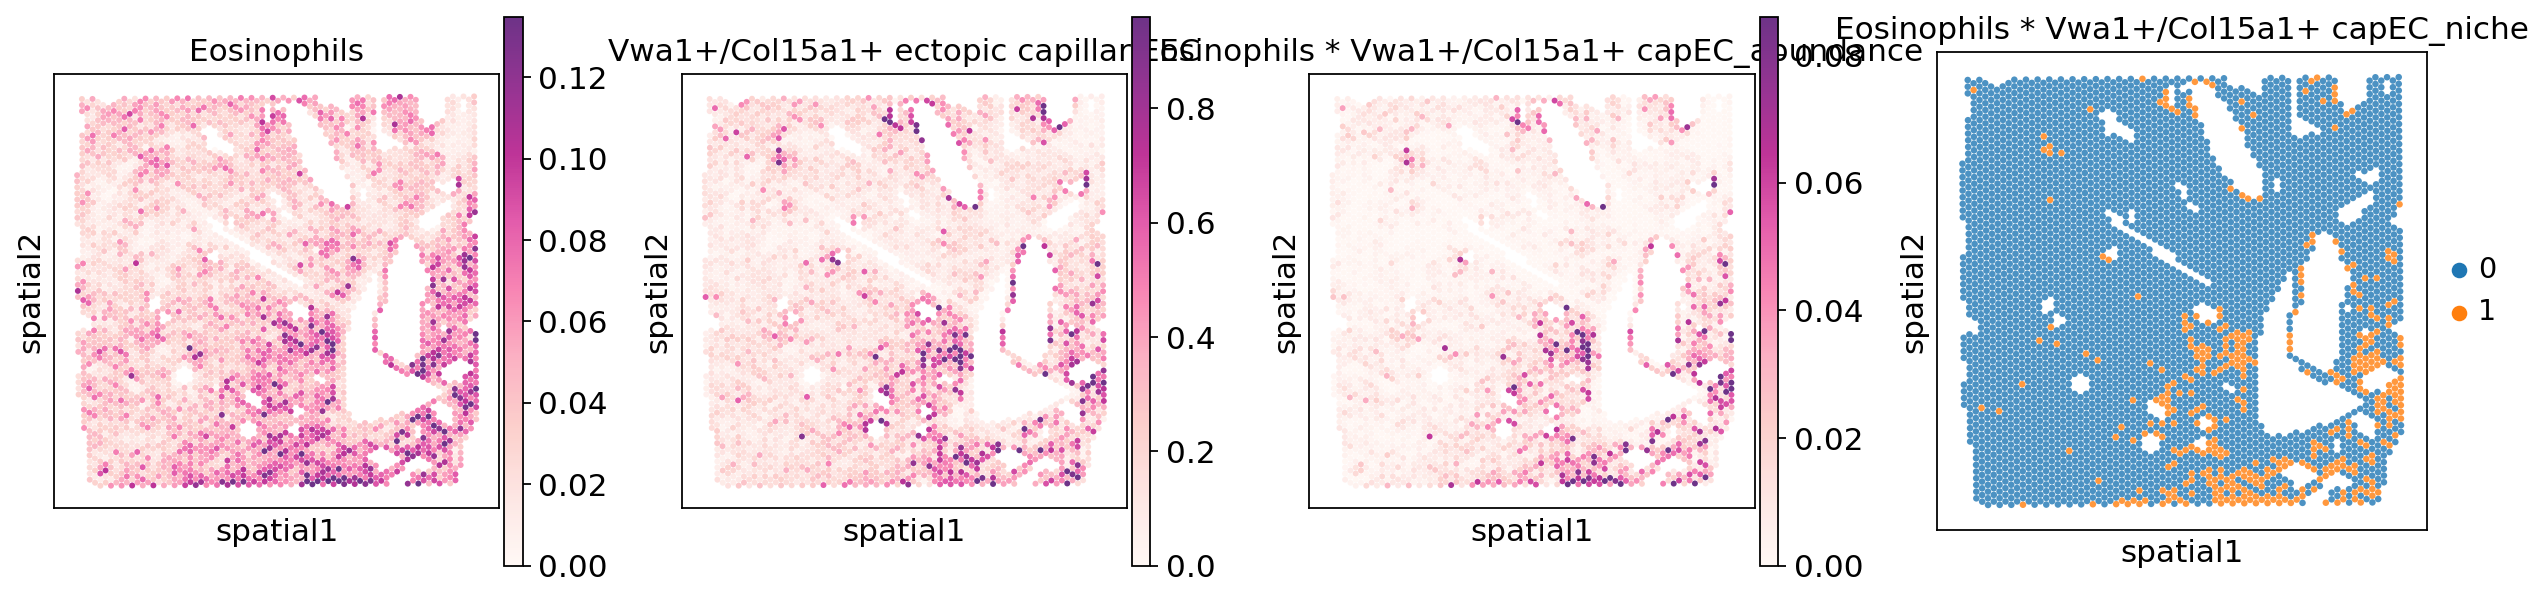

In [22]:
## plot figure
slide = c2l.utils.select_slide(adata_st, adata_st.obs['sample'].unique()[5], batch_key='sample')
## plot in spatial coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [6, 6]}):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    sc.pl.spatial(slide,
                  color=['Eosinophils'],
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[0],
                  show=False
                 )

    sc.pl.spatial(slide,
                  color=['Vwa1+/Col15a1+ ectopic capillary EC'],
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[1],
                  show=False
                 )
    sc.pl.spatial(slide,
                  color=['Eosinophils * Vwa1+/Col15a1+ capEC_abundance'],
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[2],
                  show=False
                 )
    sc.pl.spatial(slide,
                  color=['Eosinophils * Vwa1+/Col15a1+ capEC_niche'],
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[3],
                  show=False
                 )
    plt.savefig(fig_dir + 'eosinophil_alveolar_niche_visium.pdf', format='pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [23]:
## prepare metadata
sample_to_condition = dict(zip(metadata['sample_id'], metadata['condition']))

## add the condition to adata_st.obs
adata_st.obs['condition'] = adata_st.obs['sample'].map(sample_to_condition)

In [24]:
adata_st.obs['condition'].value_counts()

condition
control      12371
bleomycin    10736
Name: count, dtype: int64

In [25]:
adata_st.obs['Eosinophils * Vwa1+/Col15a1+ capEC_niche'].value_counts()

Eosinophils * Vwa1+/Col15a1+ capEC_niche
0    20674
1     2433
Name: count, dtype: int64

In [26]:
pd.crosstab(adata_st.obs['condition'], adata_st.obs['Eosinophils * Vwa1+/Col15a1+ capEC_niche'])

Eosinophils * Vwa1+/Col15a1+ capEC_niche,0,1
condition,,
bleomycin,10057,679
control,10617,1754


In [27]:
## calculcate shares of REEF niche spots

conditions = adata_st.obs['condition'].unique()
results_df = pd.DataFrame(index=[0, 1], columns=conditions)

## calculate percentages for each condition
for cond in conditions:
    
    ## filter data for this condition
    condition_data = adata_st[adata_st.obs['condition'] == cond]
    
    # total N of observations for condition
    total_obs = len(condition_data.obs)
    
    if total_obs > 0:
        ## calculate percentage for value 0 = Other
        count_0 = sum(condition_data.obs['Eosinophils * Vwa1+/Col15a1+ capEC_niche'] == 0)
        percent_0 = (count_0 / total_obs) * 100
        
        ## calculate percentage for value 1 = REEF niche
        count_1 = sum(condition_data.obs['Eosinophils * Vwa1+/Col15a1+ capEC_niche'] == 1)
        percent_1 = (count_1 / total_obs) * 100
        
        ## store results
        results_df.loc[0, cond] = percent_0
        results_df.loc[1, cond] = percent_1
    else:
        ## If no observations for this condition, set to NaN
        results_df.loc[0, cond] = np.nan
        results_df.loc[1, cond] = np.nan

## round percentages
results_df = results_df.round(2)

In [28]:
results_df

,control,bleomycin
0,0.0,0.0
1,0.0,0.0


In [29]:
## visualize results

### Characterizing the fibrotic niche?

Answering two questions here:

(1) which cell states are enriched in the fibrotic niche (compared to surrounding niche)?

(2) which cell states consistitute the fibrotic niche?

In [30]:
fibrotic_slides = adata_st[adata_st.obs['sample'].isin(adata_st.obs['sample'].unique()[3:6])]

In [31]:
# abundance mean = mean of top 10% spots
abundance_mean_thresh=0.25

## calculate mean(abundance) in the niche 
df = fibrotic_slides.obsm['q05_cell_abundance_w_sf'].copy()
df.drop(['Eosinophils * Vwa1+/Col15a1+ capEC'],axis=1,inplace=True)
df.columns=[x.replace('q05cell_abundance_w_sf_','') for x in df.columns]

In [32]:
df = df[fibrotic_slides.obs['Eosinophils * Vwa1+/Col15a1+ capEC_niche']== '1']
df = df.mean()
# df = df.apply(lambda x:np.mean(x.nlargest(n=int(len(df)*0.1))))

## select cells larger than threshold
df = df[df>abundance_mean_thresh].sort_values(ascending=False)
print(df)

cells_abundance_sel=list(df.index)
#cells_abundance_sel

Club/Ciliated                          2.573803
AT1                                    2.389899
Ciliated                               1.388769
Basal                                  1.156254
Pericytes activated                    1.023922
AT2                                    0.955155
Cd8+ T cells                           0.880444
Transitional capillary EC              0.659763
Vwa1+/Col15a1+ ectopic capillary EC    0.651965
Lipofibroblasts                        0.626914
Krt8+ ADI                              0.578601
General capillary EC                   0.307903
AT2 activated                          0.285120
B cells                                0.277411
Aerocyte capillary EC                  0.269473
M2 Macrophages                         0.257935
dtype: float32


In [33]:
## add proportion data: convert from abundance
df = adata_st.obsm['q05_cell_abundance_w_sf'].copy()
df.columns=[x.replace('q05cell_abundance_w_sf_','') for x in df.columns]
df.columns = [f'prop_{x}' for x in df.columns]
prop_df = df.apply(lambda x:x/np.sum(x), axis=1)
adata_st.obsm['prop']=prop_df.copy()

## add proportion values to the obs columns
adata_st.obs[prop_df.columns] = prop_df.copy()

#### Helper functions from TeichLab

In [34]:
def ROI_enrichment(adata, roi, target, ref='all', category_name='Annotation', prop_header='prop_'):
    
    # cells other than target cell type
    if ref=='all':
        allcells = [x.replace(prop_header,'') for x in adata.obs.columns if prop_header in x]
        others = list(set(allcells) - set(target))
    else:
        others = list(set(ref) - set(target))
    
    # extract proportion data to a dataframe
    df=adata.obs[[x for x in adata.obs.columns if prop_header in x]]
    df.columns=[x.replace(prop_header,'') for x in df.columns]
    
    # separate data into roi and non-roi spots
    df_roi = df.loc[adata.obs[adata.obs[category_name]==roi].index]
    df_nonroi = df.loc[adata.obs[adata.obs[category_name]!=roi].index]
    
    # calculate total proportion value per condition
    # contingency table: 2 annotations (ROI, non-ROI) x 2 cell categories (target cell, other cells) 
    roi_target = np.sum(df_roi[[target]])[0]
    nonroi_target = np.sum(df_nonroi[[target]])[0]
    roi_others = np.sum(np.sum(df_roi[others], axis=1))
    nonroi_others = np.sum(np.sum(df_nonroi[others], axis=1))
    
    # calculate logOR, SE, and error bar for plotting
    logOR = np.log((roi_target/nonroi_target)/(roi_others/nonroi_others))
    SE = np.sqrt((1/roi_target)+(1/nonroi_target)+(1/roi_others)+(1/nonroi_others))
    ebar = 1.96*SE
    
    # calculate chi-squared value and p-value
    table = np.array([[roi_target,nonroi_target],
                      [roi_others,nonroi_others]])
    x2, p, dof, expected = chi2_contingency(table)
    
    return dict({'logOR':logOR, 'ebar':ebar, 'x2':x2, 'p':p})

def ROI_enrichment_allcomparison(adata, roi, ref='all', category_name='Annotation', prop_header='prop_', method='fdr_bh'):
    if ref=='all':
        allcells = [x.replace(prop_header,'') for x in adata.obs.columns if prop_header in x]
        res = [ROI_enrichment(adata, roi=roi, target=x, ref=allcells, category_name=category_name, prop_header=prop_header) for x in allcells]
        res = pd.DataFrame(res)
        res['cell'] = allcells
    else:
        res = [ROI_enrichment(adata, roi=roi, target=x, ref=ref, category_name=category_name, prop_header=prop_header) for x in ref]
        res = pd.DataFrame(res)
        res['cell'] = ref
    
    res['p_adj']=smt.multipletests(res['p'], method=method, is_sorted=False, returnsorted=False)[1]
    
    return res

#### Which cell states are enriched in the fibrotic niche (compared to the surrounding tissue)?

In [35]:
## perform statistical testing
slide = adata_st[adata_st.obs['sample'].isin([adata_st.obs['sample'].unique()[5]])]

# specificity: odds ratio
logOR_thresh=0
roi='1'
category_name='Eosinophils * Vwa1+/Col15a1+ capEC_niche'
errbar_significance=False

# remove prop-cellstates which doesn't exist in the region (SAN)
#rm_list = [x for x in np.sum(slide.obs)[np.sum(slide.obs)==0].index if 'prop_' in x]
#slide.obs.drop(rm_list, axis=1, inplace=True)

res = ROI_enrichment_allcomparison(slide,
                                   roi=roi,
                                   category_name=category_name
                                  )

res = res.sort_values('logOR',ascending=False)

/home/niklas/miniconda3/envs/c2l_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/tmp/ipykernel_2082487/3938202666.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  roi_target = np.sum(df_roi[[target]])[0]
/home/niklas/miniconda3/envs/c2l_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reductio

In [36]:
## p-value cut-off
p_adj_thresh = 0.05

In [37]:
## parameters for plotting
bar_width = 0.5
region = 'Micropathological fibrotic alveolar niche'

In [38]:
## clean table before plotting - we don't want to see niche defining cell types in plot
niche_ct = ['Eosinophils * Vwa1+/Col15a1+ capEC','Vwa1+/Col15a1+ ectopic capillary EC','Eosinophils']
res = res[-res['cell'].isin(niche_ct)]

In [39]:
### overview plot
#plt.rcParams['figure.dpi'] = 120
#plt.rcParams['axes.grid'] = False
#plt.figure(figsize=(20,2.5))
#if errbar_significance:
#    res=res[(res['p_adj']<p_adj_thresh)&(res['logOR']>0)]
#    color = ['#870052' if x<p_adj_thresh else 'grey' for x in res['p_adj']]
#    plt.bar(res['cell'], res['logOR'], yerr=res['ebar'], color=color,width=bar_width)
#else:
#    if logOR_thresh!=None:
#        res=res[res['logOR']>logOR_thresh]
#    else:
#        res=res[res['logOR']>0]
#    plt.bar(res['cell'], res['logOR'], color='#870052',width=bar_width)
#        
#plt.title(f'Enriched cell states in {region}', fontdict={'fontsize':12})
#plt.ylabel('logOR',fontsize=14)
#plt.xticks(rotation= 90,fontsize=14)
#plt.yticks(fontsize=14)
#
#plt.margins(x=0.06)
#plt.show()

In [40]:
### plotting with error bars
#plt.figure(figsize=(20,2.5))
#
#color = ['#870052' if x<p_adj_thresh else 'grey' for x in res['p_adj']]
#plt.bar(res['cell'], res['logOR'], yerr=res['ebar'], color=color)
#
#plt.title(f'Enriched cell states in {region}', fontdict={'fontsize':12})
#plt.xticks(rotation= 90,fontsize=14)
#plt.ylabel('logOR',fontsize=14)
#plt.yticks(fontsize=14)
#plt.legend(handles=[plt.Rectangle((0,0),1,1, color='#870052')],
#           labels=['p_adj < '+str(p_adj_thresh)],
#           fontsize=10)
#
#plt.margins(x=0.03)
#plt.show()

In [41]:
### plot only top5 enriched cell types in this region
#res_to_plot = res.head(5)
#
### plotting
#plt.rcParams['figure.dpi'] = 120
#plt.rcParams['axes.grid'] = False
#plt.figure(figsize=(3,3))
#
#if errbar_significance:
#    res_to_plot=res_to_plot[(res['p_adj']<p_adj_thresh)&(res['logOR']>0)]
#    color = ['#870052' if x<p_adj_thresh else 'grey' for x in res_to_plot['p_adj']]
#    plt.bar(res_to_plot['cell'], res_to_plot['logOR'], yerr=res_to_plot['ebar'], color=color,width=bar_width)
#else:
#    if logOR_thresh!=None:
#        res_to_plot=res_to_plot[res_to_plot['logOR']>logOR_thresh]
#    else:
#        res_to_plot=res_to_plot[res_to_plot['logOR']>0]
#    plt.bar(res_to_plot['cell'], res_to_plot['logOR'], color='#870052',width=bar_width)
#        
#plt.title(f'Enriched cell states in {region}', fontdict={'fontsize':12})
#plt.ylabel('logOR',fontsize=14)
#plt.xticks(rotation= 90,fontsize=14)
#plt.yticks(fontsize=14)
#
#plt.margins(x=0.06)
#plt.savefig(fig_dir + 'REEF_niche_enriched_cell_states_fibrotic_alveolar_niche_visium.pdf', format='pdf', bbox_inches='tight')
#plt.show()

In [42]:
### plot only top5 enriched cell types in this region - plotting with error bars
#plt.figure(figsize=(3,3))
#
#color = ['#870052' if x<p_adj_thresh else 'grey' for x in res_to_plot['p_adj']]
#plt.bar(res_to_plot['cell'], res_to_plot['logOR'], yerr=res_to_plot['ebar'], color=color)
#
#plt.title(f'Enriched cell states in {region}', fontdict={'fontsize':12})
#plt.xticks(rotation= 90,fontsize=14)
#plt.ylabel('logOR',fontsize=14)
#plt.yticks(fontsize=14)
#plt.legend(handles=[plt.Rectangle((0,0),1,1, color='#870052')],
#           labels=['p_adj < '+str(p_adj_thresh)],
#           fontsize=10)
#
#plt.margins(x=0.03)
#plt.savefig(fig_dir + 'REEF_niche_enriched_cell_states_error_bars_visium.pdf', format='pdf', bbox_inches='tight')
#plt.show()

#### Which cell states constitute the fibrotic niche?

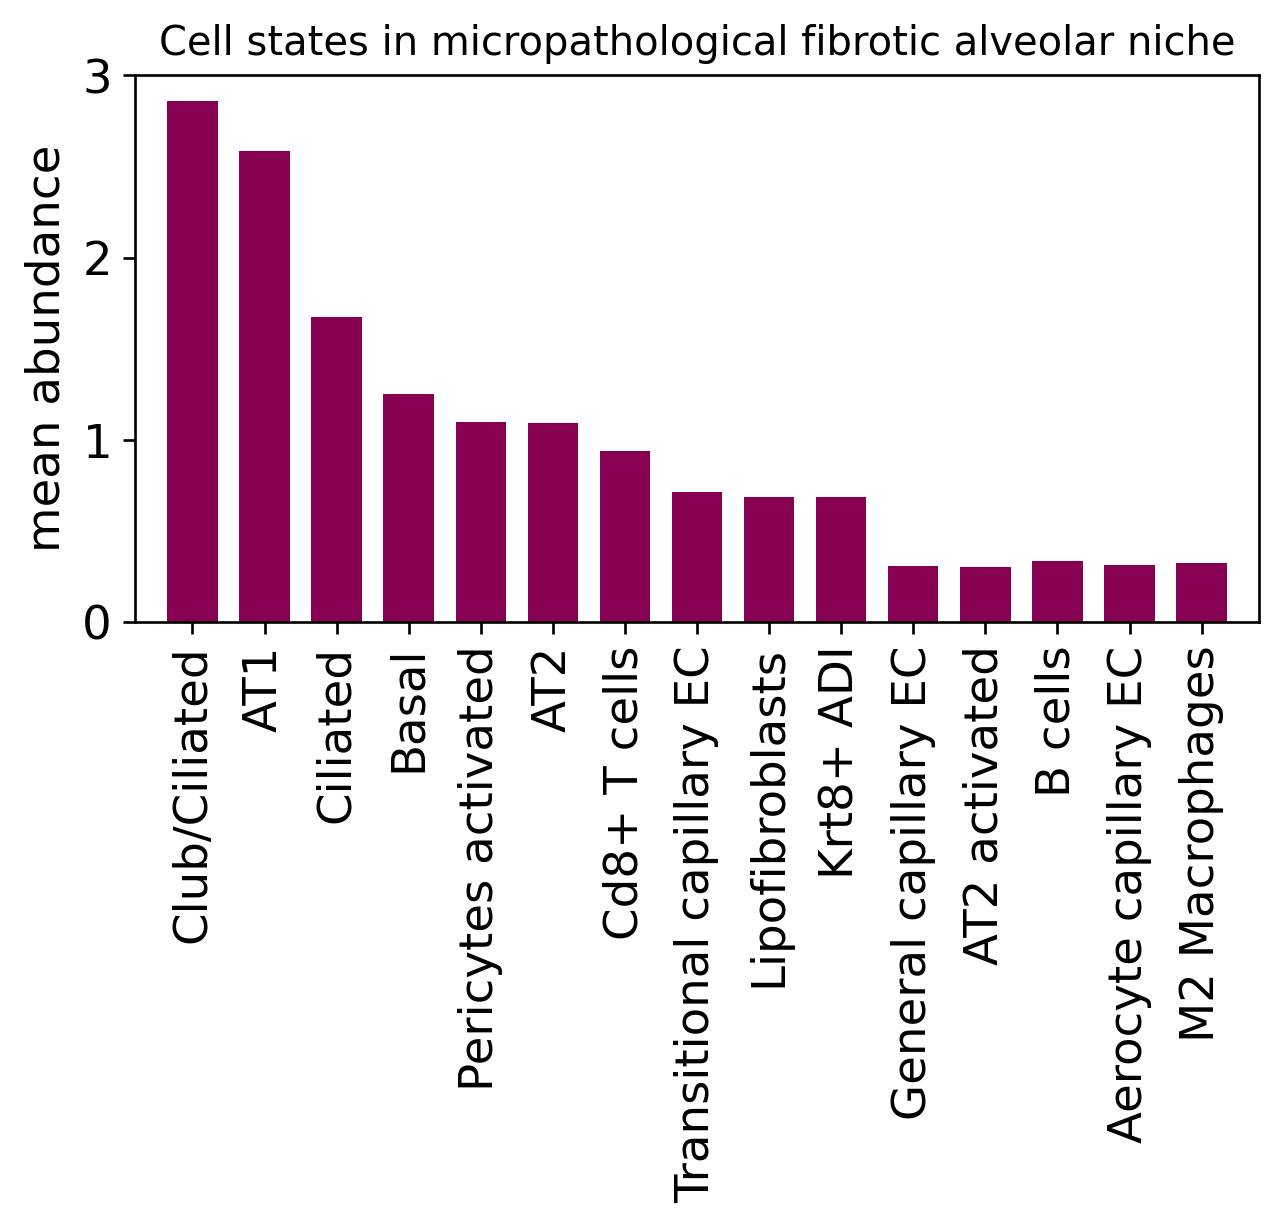

In [43]:
## intersection
cells_OR_sel=list(res['cell'])
cells_in_niche = [x for x in cells_abundance_sel if (x in cells_OR_sel)&(x not in ['Vwa1+/Col15a1+ ectopic capillary EC','Eosinophils'])]

## calculate mean(abundance) in the niche 
df = slide.obsm['q05_cell_abundance_w_sf'].copy()
df.drop(['Eosinophils * Vwa1+/Col15a1+ capEC'],axis=1,inplace=True)
df.drop(['Vwa1+/Col15a1+ ectopic capillary EC'],axis=1,inplace=True)
df.columns=[x.replace('q05cell_abundance_w_sf_','') for x in df.columns]
df = df[slide.obs['Eosinophils * Vwa1+/Col15a1+ capEC_niche']=='1']
df = df.mean()
# df = df.apply(lambda x:np.mean(x.nlargest(n=int(len(df)*0.1))))

df = df[cells_in_niche]

plt.rcParams["figure.dpi"] = 120
plt.rcParams['axes.grid'] = False
plt.figure(figsize=(6,3))
plt.bar(df.index, df, color='#870052',width=0.7)
        
plt.title('Cell states in micropathological fibrotic alveolar niche', fontdict={'fontsize':12})
plt.ylabel('mean abundance',fontsize=14)
plt.xticks(rotation= 90,fontsize=14)
plt.yticks(fontsize=14)
plt.margins(x=0.03)
plt.savefig(fig_dir + 'REEF_niche_cell_state_composition_visium.pdf', format='pdf', bbox_inches='tight')
plt.show()

#### Validation of enriched cell states in fibrotic alveolar niche

In [44]:
roi_coordinates = [9000, 10500, 8500, 10500] # [left, right, top, bottom]

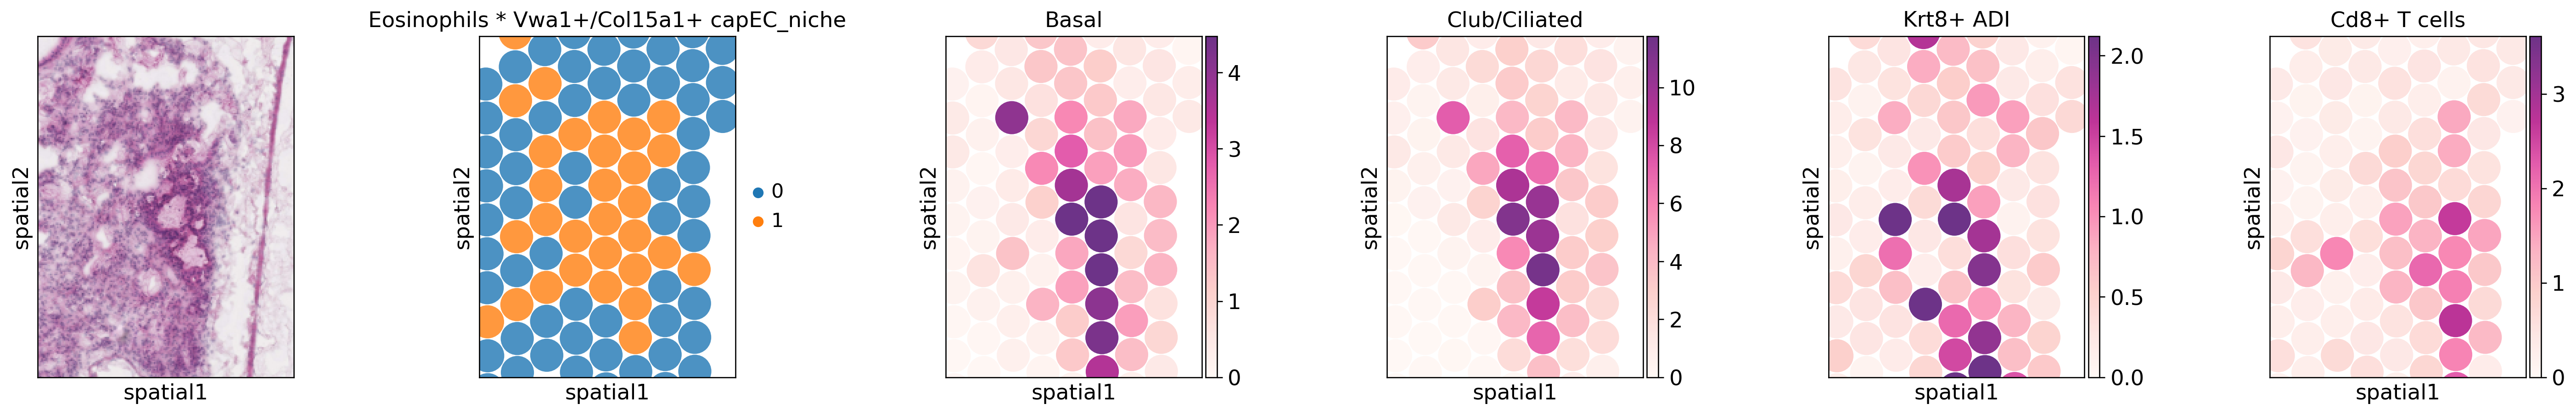

In [45]:
## plot figure
slide = c2l.utils.select_slide(adata_st, adata_st.obs['sample'].unique()[5], batch_key='sample')
## plot in spatial coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [6, 6]}):
    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    
    sc.pl.spatial(slide,
                  color=None,
                  crop_coord=roi_coordinates,
                  alpha=0.0,
                  alpha_img=1.0,
                  img_key='hires',
                  ax=axes[0],
                  show=False
                 )

    sc.pl.spatial(slide,
                  color=['Eosinophils * Vwa1+/Col15a1+ capEC_niche'],
                  crop_coord=roi_coordinates,
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[1],
                  show=False
                 )
    sc.pl.spatial(slide,
                  color=['Basal'],
                  crop_coord=roi_coordinates,
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[2],
                  show=False
                 )
    sc.pl.spatial(slide,
                  color=['Club/Ciliated'],
                  crop_coord=roi_coordinates,
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[3],
                  show=False
                 )
    sc.pl.spatial(slide,
                  color=['Krt8+ ADI'],
                  crop_coord=roi_coordinates,
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[4],
                  show=False
                 )
    sc.pl.spatial(slide,
                  color=['Cd8+ T cells'],
                  crop_coord=roi_coordinates,
                  cmap ='RdPu',
                  vmin=0,
                  vmax='p99.2',
                  size=1.5,
                  alpha=0.8,
                  img_key=None,
                  alpha_img=1,
                  ax=axes[5],
                  show=False
                 )
    plt.savefig(fig_dir + 'REEF_niche_visium_enriched_cell_states.pdf', format='pdf', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

### Specificity of recruitment and adhesion factors in niche

In [46]:
sc.tl.rank_genes_groups(
    adata_st,
    groupby='Eosinophils * Vwa1+/Col15a1+ capEC_niche',
    method='wilcoxon'
)

/home/niklas/miniconda3/envs/c2l_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:453: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/home/niklas/miniconda3/envs/c2l_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:455: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/niklas/miniconda3/envs/c2l_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:452: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


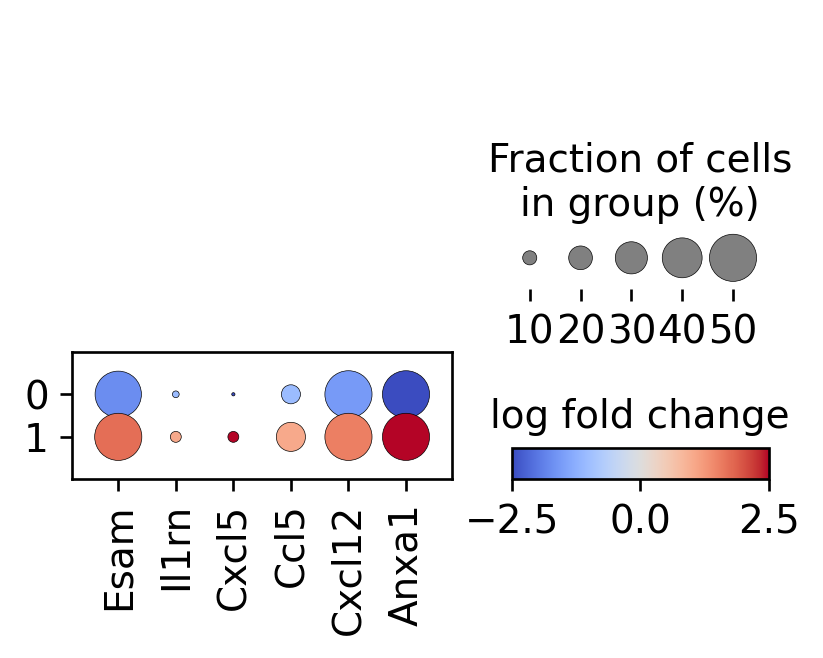

In [47]:
sc.pl.rank_genes_groups_dotplot(adata_st,
                                groupby=['Eosinophils * Vwa1+/Col15a1+ capEC_niche'],
                                var_names=['Esam','Il1rn','Cxcl5','Ccl5','Cxcl12','Anxa1'], 
                                values_to_plot='logfoldchanges',
                                dot_max=0.5,
                                vmax=2.5,
                                vmin=-2.5,
                                cmap = 'coolwarm',
                                dendrogram = False,
                                save = 'niche_specificity_recruitment_factors.pdf'
                               )